# 09 - Modelado de Clasificación V3

## Comparación de predicciones de clasificación con dataset mejorado

En este notebook vuelvo a entrenar modelos de clasificación utilizando el dataset mejorado:

`dataset_modelo_v3.csv`

Este dataset fue generado después de aplicar una limpieza más conservadora, clipping de valores extremos y nuevas variables derivadas con sentido logístico.

El objetivo principal es probar nuevamente los modelos de clasificación y comparar dos posibles predicciones:

1. `tiene_incidencia`  
   Predice si un envío tendrá o no alguna incidencia logística.

2. `entrega_tardia_v2`  
   Predice si un envío será tardío usando una regla basada en `dias_entrega > 7`.

La idea es comparar ambos enfoques y decidir cuál es más defendible para el proyecto.


# Objetivos del notebook

En este notebook busco:

- cargar el dataset mejorado V3;
- crear o validar las variables objetivo de clasificación;
- probar varios modelos de clasificación;
- comparar métricas de rendimiento;
- analizar cuál predicción es más útil;
- seleccionar el mejor enfoque de clasificación para continuar con optimización.

Los modelos probados serán:

- Logistic Regression;
- Decision Tree;
- Random Forest;
- K-Nearest Neighbors;
- Support Vector Machine;
- Gaussian Naive Bayes.


# 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Modelos de regresión importados como referencia del requerimiento.
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.pipeline import Pipeline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)


# 2. Carga del dataset V3

In [2]:
df = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

print("Dimensiones del dataset V3:", df.shape)

df.head()


Dimensiones del dataset V3: (998, 56)


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia,peso_kg_original,distancia_km_original,velocidad_promedio_km_h_original,uso_capacidad_kg_original,uso_capacidad_m3_original,uso_capacidad_kg_recalculado,uso_capacidad_m3_recalculado,antiguedad_vehiculo,densidad_carga,riesgo_operacional,riesgo_velocidad,vehiculo_exigido,sobrecarga_kg,ruta_larga,velocidad_alta,vehiculo_riesgoso_estado,via_compleja,peso_kg_log,distancia_km_log,volumen_m3_log,velocidad_promedio_km_h_log,densidad_carga_log,riesgo_operacional_log,riesgo_velocidad_log,km_recorridos_log
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1,12675.8,919.3,55.047904,1.26758,1.389268,1.26758,1.389268,4.0,445.061620,1165.286294,50605.538323,1,1,0,0,1,0,9.447529,6.824700,3.383712,4.026207,6.100457,7.061580,10.831836,9.743554
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1,13.6,679.6,36.934783,0.01360,1.128054,0.01360,1.128054,16.0,0.545506,9.242560,25100.878261,0,0,0,0,0,0,2.681022,6.522975,3.255401,3.635868,0.435351,2.326552,10.130698,11.385149
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1,2536.0,468.4,90.076923,0.12680,1.299486,0.12680,1.299486,3.0,50.167158,59.393120,42192.030769,0,0,0,0,1,1,7.838738,6.151455,3.942552,4.511704,3.935098,4.100875,10.650010,12.403718
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1,466.0,1642.4,86.899471,0.46600,0.548617,0.46600,0.548617,11.0,33.571068,765.358400,142723.691005,0,0,1,0,0,1,6.146329,7.404523,2.700018,4.476194,3.543017,6.641650,11.868673,12.321963
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1,4928.9,1556.6,86.960894,0.98578,0.008961,0.98578,0.008961,3.0,11176.643991,1534.465148,135363.327374,1,0,1,0,0,0,8.503074,7.350901,0.364643,4.476892,9.321671,7.336589,11.815725,11.836891


# 3. Revisión general del dataset

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 56 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_envio                          998 non-null    float64
 1   fecha_envio                       461 non-null    object 
 2   id_ruta                           998 non-null    float64
 3   id_vehiculo                       998 non-null    float64
 4   peso_kg                           998 non-null    float64
 5   volumen_m3                        998 non-null    float64
 6   tipo_carga                        998 non-null    object 
 7   estado                            998 non-null    object 
 8   fecha_entrega                     463 non-null    object 
 9   origen                            998 non-null    object 
 10  destino                           998 non-null    object 
 11  distancia_km                      998 non-null    float64
 12  tiempo_e

In [4]:
nulos = df.isnull().sum().sort_values(ascending=False)

nulos[nulos > 0].head(20)



fecha_envio                     537
fecha_entrega                   535
capacidad_m3                     27
capacidad_kg                     27
estado_vehiculo                  27
km_recorridos                    27
placa                            27
año_fabricacion                  27
tipo                             27
uso_capacidad_m3_recalculado     27
riesgo_operacional_log           27
km_recorridos_log                27
riesgo_operacional               27
antiguedad_vehiculo              27
uso_capacidad_kg_recalculado     27
dtype: int64

## Análisis

El dataset V3 conserva una mayor cantidad de registros que la versión V2, lo cual es importante para el entrenamiento.

Los valores nulos restantes serán tratados dentro del pipeline usando imputación, evitando eliminar más datos innecesariamente.


# 4. Definición de targets de clasificación

Se comparan dos posibles variables objetivo:

## 1. `tiene_incidencia`
Indica si un envío presentó al menos una incidencia.

## 2. `entrega_tardia_v2`
Se construye a partir de `dias_entrega`:

- `1` si `dias_entrega > 7`
- `0` si `dias_entrega <= 7`

No se utiliza la variable antigua `entrega_tardia`, porque anteriormente quedó demasiado desbalanceada.


In [5]:
df["tiene_incidencia"] = df["tiene_incidencia"].astype(int)

df["entrega_tardia_v2"] = np.where(
    df["dias_entrega"] > 7,
    1,
    0
)

print("Distribución tiene_incidencia:")
print(df["tiene_incidencia"].value_counts())
print(df["tiene_incidencia"].value_counts(normalize=True) * 100)

print("\nDistribución entrega_tardia_v2:")
print(df["entrega_tardia_v2"].value_counts())
print(df["entrega_tardia_v2"].value_counts(normalize=True) * 100)


Distribución tiene_incidencia:
tiene_incidencia
0    834
1    164
Name: count, dtype: int64
tiene_incidencia
0    83.567134
1    16.432866
Name: proportion, dtype: float64

Distribución entrega_tardia_v2:
entrega_tardia_v2
0    900
1     98
Name: count, dtype: int64
entrega_tardia_v2
0    90.180361
1     9.819639
Name: proportion, dtype: float64


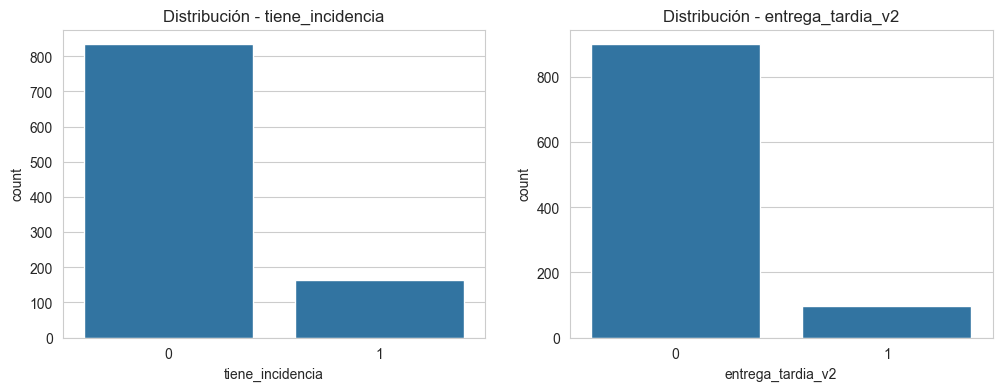

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(data=df, x="tiene_incidencia", ax=axes[0])
axes[0].set_title("Distribución - tiene_incidencia")

sns.countplot(data=df, x="entrega_tardia_v2", ax=axes[1])
axes[1].set_title("Distribución - entrega_tardia_v2")

plt.show()


## Análisis de targets

Esta comparación es fundamental antes de entrenar.

Si una variable objetivo está demasiado desbalanceada, los modelos pueden obtener un accuracy alto sin aprender realmente a detectar la clase minoritaria.

Por eso se comparan ambas predicciones antes de elegir cuál resulta más defendible.


# 5. Variables predictoras

Se utilizan variables originales tratadas y variables derivadas creadas en el feature engineering V3.

No se incluyen variables que generen fuga de información, como:

- `cantidad_incidencias`;
- `costo_total_incidencias`;
- `tipo_incidencia_principal`.

Estas variables están directamente relacionadas con el resultado de una incidencia y no deberían usarse para predecir si ocurrirá.


In [7]:
variables_base = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo",
    "tipo",

    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",

    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_operacional",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "vehiculo_riesgoso_estado",
    "via_compleja",

    "peso_kg_log",
    "distancia_km_log",
    "volumen_m3_log",
    "velocidad_promedio_km_h_log",
    "densidad_carga_log",
    "riesgo_operacional_log",
    "riesgo_velocidad_log",
    "km_recorridos_log"
]

variables_modelo = [col for col in variables_base if col in df.columns]

print("Cantidad de variables utilizadas:", len(variables_modelo))
print(variables_modelo)


Cantidad de variables utilizadas: 34
['distancia_km', 'tiempo_estimado_hrs', 'peso_kg', 'volumen_m3', 'capacidad_kg', 'capacidad_m3', 'velocidad_promedio_km_h', 'km_recorridos', 'tipo_via', 'tipo_carga', 'estado_vehiculo', 'tipo', 'uso_capacidad_kg', 'uso_capacidad_m3', 'uso_capacidad_kg_recalculado', 'uso_capacidad_m3_recalculado', 'antiguedad_vehiculo', 'densidad_carga', 'riesgo_operacional', 'riesgo_velocidad', 'vehiculo_exigido', 'sobrecarga_kg', 'ruta_larga', 'velocidad_alta', 'vehiculo_riesgoso_estado', 'via_compleja', 'peso_kg_log', 'distancia_km_log', 'volumen_m3_log', 'velocidad_promedio_km_h_log', 'densidad_carga_log', 'riesgo_operacional_log', 'riesgo_velocidad_log', 'km_recorridos_log']


# 6. Funciones auxiliares

In [8]:
def preparar_datos(df, target, variables_modelo):
    """Prepara X, y y listas de variables numéricas/categóricas."""

    X = df[variables_modelo].copy()
    y = df[target].copy()

    variables_numericas = X.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    return X, y, variables_numericas, variables_categoricas


def crear_preprocesador(variables_numericas, variables_categoricas):
    """Crea un ColumnTransformer para variables numéricas y categóricas."""

    transformador_numerico = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    transformador_categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocesador = ColumnTransformer([
        ("num", transformador_numerico, variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ])

    return preprocesador


# 7. Función de evaluación de modelos

Esta función entrena varios modelos de clasificación y devuelve sus métricas principales.

El foco estará en:

- `f1_score`;
- `recall`;
- `balanced_accuracy`.

El F1-score será la métrica principal porque combina precision y recall.


In [9]:
def evaluar_modelos_clasificacion(df, target, variables_modelo):
    """Entrena y evalúa varios modelos de clasificación para un target."""

    X, y, variables_numericas, variables_categoricas = preparar_datos(
        df,
        target,
        variables_modelo
    )

    print(f"Target evaluado: {target}")
    print("\nDistribución del target:")
    print(y.value_counts())
    print(y.value_counts(normalize=True) * 100)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    preprocesador = crear_preprocesador(
        variables_numericas,
        variables_categoricas
    )

    modelos = {
        "Logistic Regression": LogisticRegression(
            random_state=42,
            max_iter=3000,
            class_weight="balanced"
        ),
        "Decision Tree": DecisionTreeClassifier(
            random_state=42,
            max_depth=6,
            class_weight="balanced"
        ),
        "Random Forest": RandomForestClassifier(
            random_state=42,
            n_estimators=200,
            max_depth=8,
            class_weight="balanced"
        ),
        "KNN": KNeighborsClassifier(
            n_neighbors=5
        ),
        "SVM": SVC(
            random_state=42,
            class_weight="balanced",
            probability=True
        ),
        "Gaussian NB": GaussianNB()
    }

    resultados = []
    modelos_entrenados = {}

    for nombre, modelo in modelos.items():

        pipeline = Pipeline([
            ("preprocesamiento", preprocesador),
            ("modelo", modelo)
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        matriz = confusion_matrix(y_test, y_pred)

        resultados.append({
            "target": target,
            "modelo": nombre,
            "accuracy": accuracy,
            "balanced_accuracy": balanced_acc,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "matriz_confusion": matriz
        })

        modelos_entrenados[nombre] = {
            "pipeline": pipeline,
            "X_test": X_test,
            "y_test": y_test,
            "y_pred": y_pred
        }

    tabla = pd.DataFrame(resultados)

    return tabla, modelos_entrenados


# 8. Experimento 1: predicción de `tiene_incidencia`

En este primer experimento se predice si un envío tendrá o no incidencias logísticas.


In [10]:
tabla_incidencia, modelos_incidencia = evaluar_modelos_clasificacion(
    df=df,
    target="tiene_incidencia",
    variables_modelo=variables_modelo
)

tabla_incidencia.sort_values(by="f1_score", ascending=False)


Target evaluado: tiene_incidencia

Distribución del target:
tiene_incidencia
0    834
1    164
Name: count, dtype: int64
tiene_incidencia
0    83.567134
1    16.432866
Name: proportion, dtype: float64


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,matriz_confusion
1,tiene_incidencia,Decision Tree,0.500,0.493921,0.161616,0.484848,0.242424,"[[84, 83], [17, 16]]"
5,tiene_incidencia,Gaussian NB,0.765,0.543186,0.250000,0.212121,0.229508,"[[146, 21], [26, 7]]"
0,tiene_incidencia,Logistic Regression,0.560,0.481219,0.151899,0.363636,0.214286,"[[100, 67], [21, 12]]"
4,tiene_incidencia,SVM,0.580,0.481038,0.150685,0.333333,0.207547,"[[105, 62], [22, 11]]"
3,tiene_incidencia,KNN,0.785,0.506532,0.187500,0.090909,0.122449,"[[154, 13], [30, 3]]"
2,tiene_incidencia,Random Forest,0.820,0.515333,0.285714,0.060606,0.100000,"[[162, 5], [31, 2]]"


## Análisis del experimento de incidencias

Después de ejecutar esta celda, se debe revisar:

- qué modelo obtiene mayor F1-score;
- qué modelo logra mejor recall;
- si el accuracy es engañoso;
- si los modelos realmente detectan la clase positiva.

La predicción de incidencias será defendible si logra un F1-score razonable y si el recall no queda demasiado bajo.


# 9. Experimento 2: predicción de `entrega_tardia_v2`

En este segundo experimento se predice si una entrega será tardía usando la variable:

`entrega_tardia_v2 = dias_entrega > 7`


In [11]:
tabla_tardia, modelos_tardia = evaluar_modelos_clasificacion(
    df=df,
    target="entrega_tardia_v2",
    variables_modelo=variables_modelo
)

tabla_tardia.sort_values(by="f1_score", ascending=False)


Target evaluado: entrega_tardia_v2

Distribución del target:
entrega_tardia_v2
0    900
1     98
Name: count, dtype: int64
entrega_tardia_v2
0    90.180361
1     9.819639
Name: proportion, dtype: float64


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,matriz_confusion
1,entrega_tardia_v2,Decision Tree,0.675,0.575000,0.142857,0.45,0.216867,"[[126, 54], [11, 9]]"
4,entrega_tardia_v2,SVM,0.700,0.544444,0.129630,0.35,0.189189,"[[133, 47], [13, 7]]"
0,entrega_tardia_v2,Logistic Regression,0.570,0.494444,0.097561,0.40,0.156863,"[[106, 74], [12, 8]]"
5,entrega_tardia_v2,Gaussian NB,0.840,0.511111,0.125000,0.10,0.111111,"[[166, 14], [18, 2]]"
3,entrega_tardia_v2,KNN,0.885,0.491667,0.000000,0.00,0.000000,"[[177, 3], [20, 0]]"
2,entrega_tardia_v2,Random Forest,0.900,0.500000,0.000000,0.00,0.000000,"[[180, 0], [20, 0]]"


## Análisis del experimento de entrega tardía

Aquí se debe verificar si la predicción de retraso tiene mejores métricas que la predicción de incidencias.

Si el target tiene poca señal o está mal distribuido, los modelos podrían seguir mostrando F1-score bajo.


# 10. Comparación general de ambos targets

In [12]:
tabla_comparativa = pd.concat(
    [tabla_incidencia, tabla_tardia],
    ignore_index=True
)

tabla_comparativa.sort_values(by="f1_score", ascending=False)


,target,modelo,accuracy,balanced_accuracy,precision,recall,f1_score,matriz_confusion
1,tiene_incidencia,Decision Tree,0.500,0.493921,0.161616,0.484848,0.242424,"[[84, 83], [17, 16]]"
5,tiene_incidencia,Gaussian NB,0.765,0.543186,0.250000,0.212121,0.229508,"[[146, 21], [26, 7]]"
7,entrega_tardia_v2,Decision Tree,0.675,0.575000,0.142857,0.450000,0.216867,"[[126, 54], [11, 9]]"
0,tiene_incidencia,Logistic Regression,0.560,0.481219,0.151899,0.363636,0.214286,"[[100, 67], [21, 12]]"
4,tiene_incidencia,SVM,0.580,0.481038,0.150685,0.333333,0.207547,"[[105, 62], [22, 11]]"
10,entrega_tardia_v2,SVM,0.700,0.544444,0.129630,0.350000,0.189189,"[[133, 47], [13, 7]]"
6,entrega_tardia_v2,Logistic Regression,0.570,0.494444,0.097561,0.400000,0.156863,"[[106, 74], [12, 8]]"
3,tiene_incidencia,KNN,0.785,0.506532,0.187500,0.090909,0.122449,"[[154, 13], [30, 3]]"
11,entrega_tardia_v2,Gaussian NB,0.840,0.511111,0.125000,0.100000,0.111111,"[[166, 14], [18, 2]]"
2,tiene_incidencia,Random Forest,0.820,0.515333,0.285714,0.060606,0.100000,"[[162, 5], [31, 2]]"


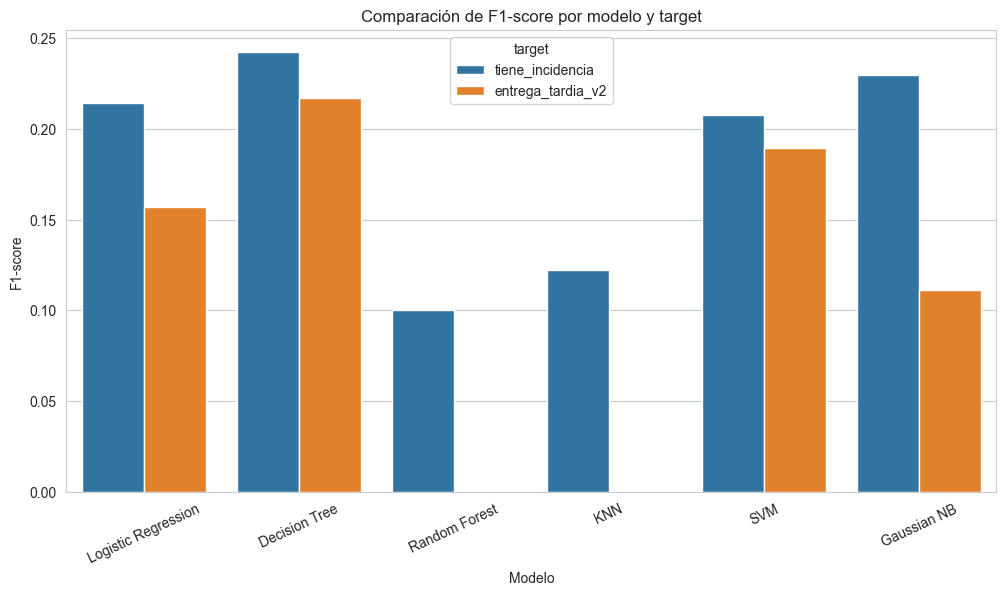

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=tabla_comparativa,
    x="modelo",
    y="f1_score",
    hue="target"
)

plt.title("Comparación de F1-score por modelo y target")
plt.xlabel("Modelo")
plt.ylabel("F1-score")
plt.xticks(rotation=25)

plt.show()


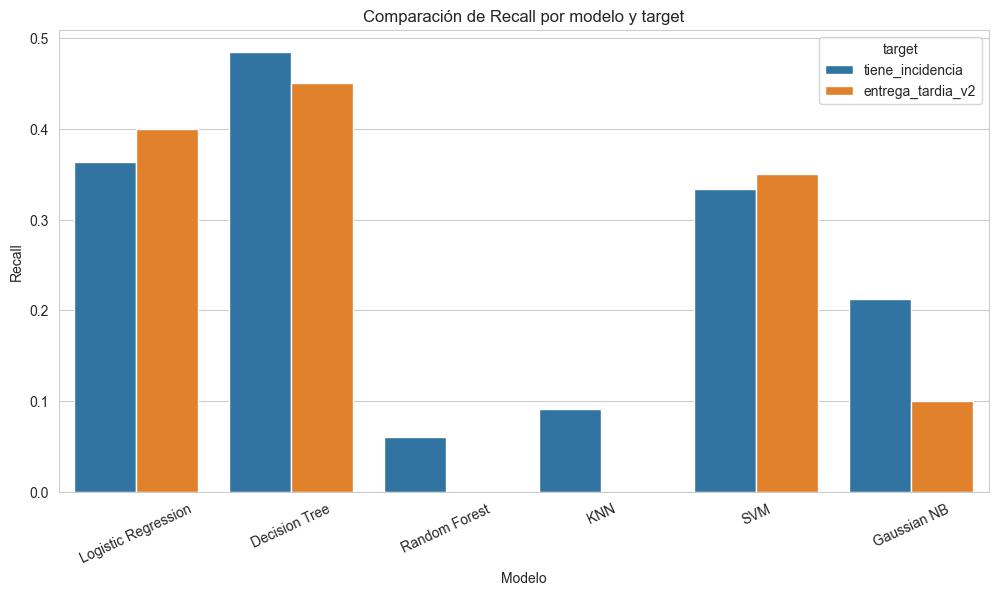

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=tabla_comparativa,
    x="modelo",
    y="recall",
    hue="target"
)

plt.title("Comparación de Recall por modelo y target")
plt.xlabel("Modelo")
plt.ylabel("Recall")
plt.xticks(rotation=25)

plt.show()


## Análisis comparativo

Esta comparación permite decidir cuál predicción es más defendible.

Un target será más fuerte si:

- tiene mejor F1-score;
- mantiene buen recall;
- no depende únicamente de accuracy;
- tiene sentido operacional;
- y presenta una distribución de clases utilizable.


# 11. Selección automática del mejor modelo global

In [15]:
mejor_resultado = tabla_comparativa.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

mejor_resultado



target                   tiene_incidencia
modelo                      Decision Tree
accuracy                              0.5
balanced_accuracy                0.493921
precision                        0.161616
recall                           0.484848
f1_score                         0.242424
matriz_confusion     [[84, 83], [17, 16]]
Name: 1, dtype: object

# 12. Matriz de confusión del mejor modelo

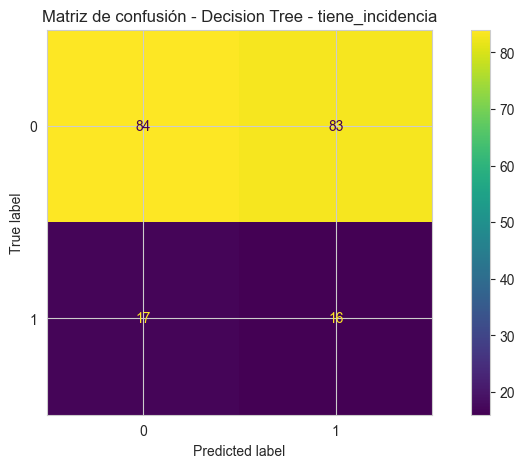

In [16]:
mejor_target = mejor_resultado["target"]
mejor_modelo_nombre = mejor_resultado["modelo"]

if mejor_target == "tiene_incidencia":
    info_modelo = modelos_incidencia[mejor_modelo_nombre]
else:
    info_modelo = modelos_tardia[mejor_modelo_nombre]

matriz = confusion_matrix(
    info_modelo["y_test"],
    info_modelo["y_pred"]
)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz)

disp.plot()

plt.title(f"Matriz de confusión - {mejor_modelo_nombre} - {mejor_target}")

plt.show()


# 13. Classification report del mejor modelo

In [17]:
print("Mejor target:", mejor_target)
print("Mejor modelo:", mejor_modelo_nombre)

print("\nClassification Report:")
print(
    classification_report(
        info_modelo["y_test"],
        info_modelo["y_pred"],
        zero_division=0
    )
)


Mejor target: tiene_incidencia
Mejor modelo: Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.50      0.63       167
           1       0.16      0.48      0.24        33

    accuracy                           0.50       200
   macro avg       0.50      0.49      0.43       200
weighted avg       0.72      0.50      0.56       200



# 14. Curva ROC del mejor modelo

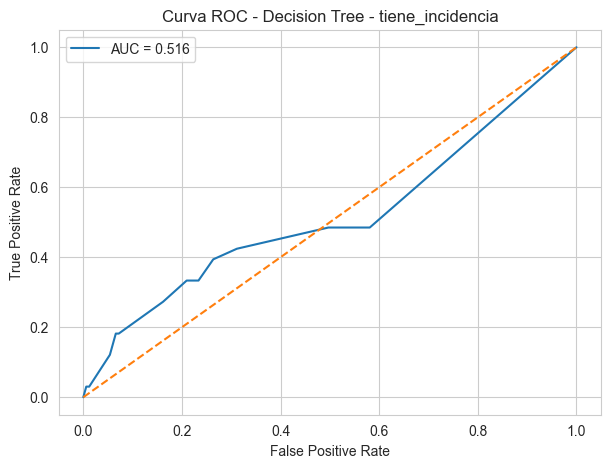

In [18]:
pipeline_mejor = info_modelo["pipeline"]
X_test_mejor = info_modelo["X_test"]
y_test_mejor = info_modelo["y_test"]

try:
    y_score = pipeline_mejor.predict_proba(X_test_mejor)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test_mejor, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {mejor_modelo_nombre} - {mejor_target}")
    plt.legend()

    plt.show()

except Exception as e:
    print("No fue posible calcular curva ROC para este modelo.")
    print(e)


# 15. Importancia de variables si el mejor modelo es basado en árboles

,variable,importancia
5,num__capacidad_m3,0.120881
29,num__km_recorridos_log,0.094855
25,num__velocidad_promedio_km_h_log,0.080617
14,num__riesgo_operacional,0.079244
28,num__riesgo_velocidad_log,0.074722
27,num__riesgo_operacional_log,0.070587
26,num__densidad_carga_log,0.056455
7,num__km_recorridos,0.050492
9,num__uso_capacidad_m3,0.043221
11,num__uso_capacidad_m3_recalculado,0.038669


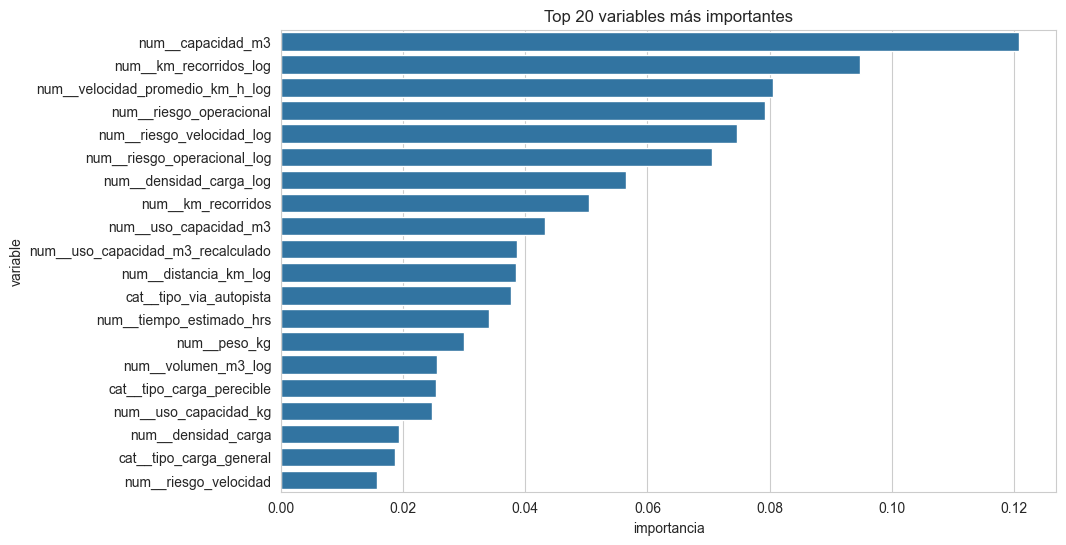

In [19]:
try:
    modelo_final = pipeline_mejor.named_steps["modelo"]
    preprocesador_final = pipeline_mejor.named_steps["preprocesamiento"]

    if hasattr(modelo_final, "feature_importances_"):

        nombres_features = preprocesador_final.get_feature_names_out()

        importancias = pd.DataFrame({
            "variable": nombres_features,
            "importancia": modelo_final.feature_importances_
        }).sort_values(by="importancia", ascending=False)

        display(importancias.head(20))

        plt.figure(figsize=(10,6))

        sns.barplot(
            data=importancias.head(20),
            x="importancia",
            y="variable"
        )

        plt.title("Top 20 variables más importantes")
        plt.show()

    else:
        print("El mejor modelo no tiene feature_importances_.")

except Exception as e:
    print("No fue posible obtener importancia de variables.")
    print(e)


# 16. Conclusiones finales

En este notebook se probaron dos problemas de clasificación usando el dataset V3:

1. Predicción de incidencias.
2. Predicción de entrega tardía corregida.

Además, se entrenaron distintos modelos de clasificación:

- Logistic Regression;
- Decision Tree;
- Random Forest;
- KNN;
- SVM;
- Gaussian Naive Bayes.

La decisión final debe basarse principalmente en F1-score, recall y sentido operacional del problema.

Si `tiene_incidencia` obtiene mejores métricas, será la predicción principal porque permite anticipar riesgos logísticos.

Si `entrega_tardia_v2` obtiene mejores resultados, podría utilizarse como predicción alternativa relacionada con cumplimiento de tiempos.

El siguiente paso será optimizar hiperparámetros del mejor modelo y target mediante GridSearchCV u Optuna.
